# 11 — Biodiesel: observed-interval training (experiment)

**What changes.** Normal training (`chemkan/scripts/train_biodiesel.py`) integrates each
training trajectory from its *t* = 0 state over the whole 30 s and scores the complete
predicted trajectory (Eq. 18). Interval training
(`chemkan/scripts/train_biodiesel_observed_intervals.py`) restarts every interval
[*t*<sub>j</sub>, *t*<sub>j+1</sub>] from the **observed** state at *t*<sub>j</sub>,
integrates across that one interval, and scores only its endpoint. The gradients of all
29 intervals are added and one Adam step is taken per epoch, so both methods make 10,000
updates. The model (156 parameters), learning rate, solver and loss formula are unchanged.

**How it is scored.** The interval objective is an easier task — errors can never build up
over time — so its value is never compared with anything. Every comparison below is a
**full rollout**: the trained model is integrated from each trajectory's *t* = 0 state
over the whole grid with no resets, exactly like normal training.

Interval training is an additional experiment; the ChemKAN paper does not
describe it. Clean data, seeds 0, 1, 2. This notebook trains nothing.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for sub in ("src", "scripts", "scripts/figures"):
    sys.path.insert(0, str(ROOT / "chemkan" / sub))

from chemkan.normalization import MinMaxNormalizer
from evaluate_biodiesel import build_kinetic_core, solver_from_ckpt, integrate_biodiesel
from _data import load_biodiesel, load_input_scaling

EXP  = ROOT / "results/experiments/biodiesel_observed_intervals"
FIGS = EXP / "figures"
TABS = EXP / "tables"
SEEDS = [0, 1, 2]

# The two runs of a seed start from identical initial weights.
INTERVAL = {s: EXP / f"seed{s}" for s in SEEDS}
ORIGINAL = {
    # Seed 0 is the reproduction's clean run (clean_replay_seed0: a bit-identical re-run
    # of main/direct_autograd_seed0 that also logged the test loss every epoch).
    0: ROOT / "results/reproduction/chemkan/biodiesel/noise/clean_replay_seed0",
    1: EXP / "baseline_original_seed1",
    2: EXP / "baseline_original_seed2",
}

TRAIN, TEST = load_biodiesel("train"), load_biodiesel("test")
species = [str(s) for s in TRAIN["species"]]
print("species:", species)
print(f"train / test trajectories: {TRAIN['Y0'].shape[0]} / {TEST['Y0'].shape[0]}, "
      f"{len(TRAIN['t'])} saved times over {float(TRAIN['t'][-1]):.0f} s")

species: ['TG', 'ROH', 'DG', 'MG', 'GL', 'RCO2R']
train / test trajectories: 20 / 10, 30 saved times over 30 s


## 1. Full-rollout error at 10,000 updates

`evaluate` is the only place this notebook runs a model. It loads a run's final
checkpoint, integrates from every trajectory's *t* = 0 state over all 30 saved times, and
compares the result with the clean data after train-only min-max normalization. For each
species the squared error is summed over time and averaged over trajectories; the Eq. 18
loss is the mean of those six numbers. Lower is better, and a negative Δ means interval
training helped.

In [3]:
NORM = MinMaxNormalizer(TRAIN["u_min"], TRAIN["u_max"])      # train-only statistics
DATA = {"train": TRAIN, "test": TEST}

@torch.no_grad()
def evaluate(run_dir, split):
    """Per-species full-rollout error of a run's final model on one split -> (6,)."""
    ckpt = torch.load(run_dir / "checkpoint_final.pt", map_location="cpu", weights_only=False)
    core = build_kinetic_core(ckpt, len(species), "cpu")
    d = DATA[split]
    pred = integrate_biodiesel(core, load_input_scaling(ckpt, "cpu"), solver_from_ckpt(ckpt),
                               d["Y0"], d["T_const"], d["t"])          # (30 times, B, 6)
    sq = (NORM.normalize(pred) - NORM.normalize(d["species_TBm"])) ** 2
    return sq.sum(dim=0).mean(dim=0).numpy()       # sum over time, mean over trajectories

# errors[method, seed, split] = per-species error; its mean is the Eq. 18 loss.
errors = {(method, s, split): evaluate(runs[s], split)
          for method, runs in (("interval", INTERVAL), ("original", ORIGINAL))
          for s in SEEDS for split in ("train", "test")}

rows = []
for s in SEEDS:
    r = {"seed": s}
    for split in ("train", "test"):
        r[f"obs_{split}"] = float(errors["interval", s, split].mean())
        r[f"orig_{split}"] = float(errors["original", s, split].mean())
    for split in ("train", "test"):
        r[f"d_{split}"] = r[f"obs_{split}"] - r[f"orig_{split}"]
    for split in ("train", "test"):
        r[f"ratio_{split}"] = r[f"obs_{split}"] / r[f"orig_{split}"]
    rows.append(r)

print(f"{'seed':>4} | {'train: interval':>15} {'normal':>8} {'Δ':>9} | "
      f"{'test: interval':>14} {'normal':>8} {'Δ':>9}")
for r in rows:
    print(f"{r['seed']:>4} | {r['obs_train']:>15.5f} {r['orig_train']:>8.5f} {r['d_train']:>+9.5f} | "
          f"{r['obs_test']:>14.5f} {r['orig_test']:>8.5f} {r['d_test']:>+9.5f}")
print(f"\ninterval training better on train in {sum(r['d_train'] < 0 for r in rows)}/3 seeds, "
      f"on test in {sum(r['d_test'] < 0 for r in rows)}/3 seeds")

with open(TABS / "observed_intervals_final_comparison.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0]))
    w.writeheader(); w.writerows(rows)

seed | train: interval   normal         Δ | test: interval   normal         Δ
   0 |         0.03255  0.06202  -0.02946 |        0.08502  0.08140  +0.00362
   1 |         0.02325  0.02247  +0.00078 |        0.06733  0.06324  +0.00408
   2 |         0.01814  0.03312  -0.01498 |        0.07055  0.05567  +0.01488

interval training better on train in 2/3 seeds, on test in 0/3 seeds


## 2. Error by species

The same numbers as the table above, split by species and averaged over the three seeds.

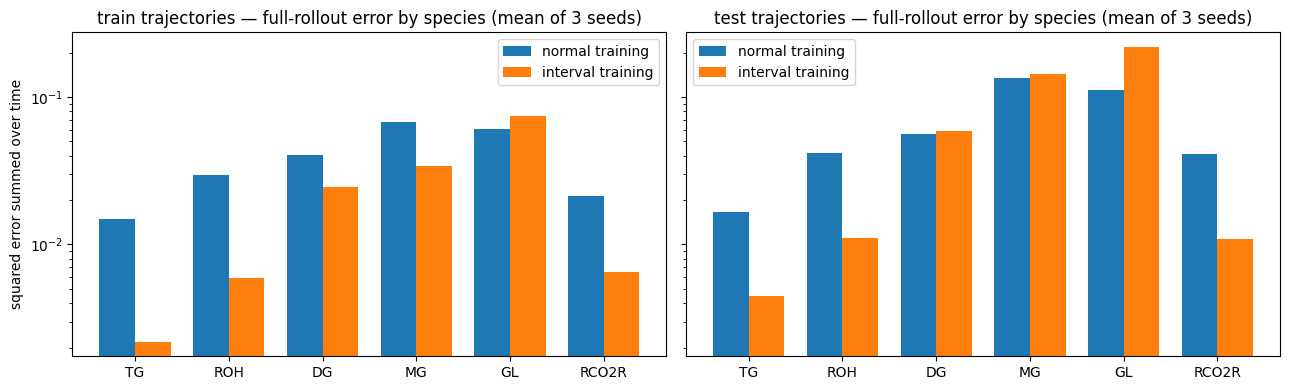

In [4]:
x, width = np.arange(len(species)), 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, split in zip(axes, ("train", "test")):
    for offset, method, label in ((-width / 2, "original", "normal training"),
                                  (+width / 2, "interval", "interval training")):
        mean = np.mean([errors[method, s, split] for s in SEEDS], axis=0)
        ax.bar(x + offset, mean, width, label=label)
    ax.set_xticks(x, species)
    ax.set_yscale("log")
    ax.set_title(f"{split} trajectories — full-rollout error by species (mean of 3 seeds)")
    ax.legend()
axes[0].set_ylabel("squared error summed over time")
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_per_species.pdf")
fig.savefig(FIGS / "observed_intervals_per_species.png", dpi=150)
plt.show()

with open(TABS / "observed_intervals_error_breakdown.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "seed", "procedure", *[f"species_{sp}" for sp in species], "total"])
    for (method, s, split), v in errors.items():
        name = "observed_interval" if method == "interval" else "original"
        w.writerow([split, s, name, *map(float, v), float(v.mean())])

## 3. Training curves

Both panels show the full-rollout loss recorded **during** training (Eq. 18,
time-summed): solid = interval training, dashed = normal training, one colour per seed.
Interval runs evaluated the full rollout every 100 updates; normal runs did so every
update, which is why their curves look noisier. The loss each run actually minimized is
plotted below.

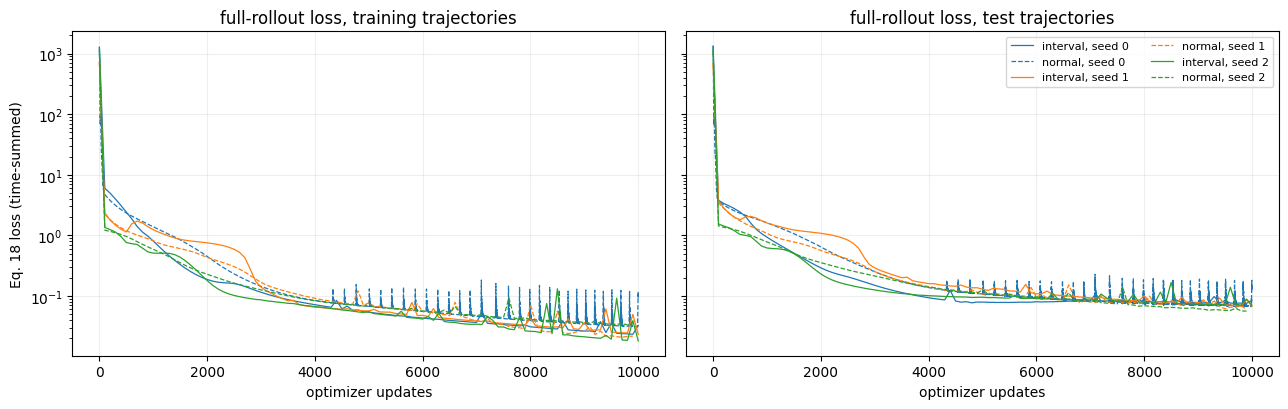

In [5]:
def history(run_dir):
    """(updates, full-rollout train loss, full-rollout clean test loss) from history.csv."""
    with open(run_dir / "history.csv", newline="") as f:
        rows = list(csv.DictReader(f))
    if "full_rollout_train_mse" in rows[0]:      # interval run: its own columns, every 100 updates
        train_col, test_col = "full_rollout_train_mse", "full_rollout_test_mse_clean"
    else:                                          # normal run: total_loss IS the full rollout
        train_col, test_col = "total_loss", "test_mse_clean"
    rows = [r for r in rows if r[train_col] and r[test_col]]
    return (np.array([float(r["epoch"]) for r in rows]),
            np.array([float(r[train_col]) for r in rows]),
            np.array([float(r[test_col]) for r in rows]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for s, color in zip(SEEDS, ("tab:blue", "tab:orange", "tab:green")):
    for runs, style, label in ((INTERVAL, "-", "interval"), (ORIGINAL, "--", "normal")):
        e, train, test = history(runs[s])
        axes[0].semilogy(e, train, style, color=color, lw=0.9, label=f"{label}, seed {s}")
        axes[1].semilogy(e, test, style, color=color, lw=0.9, label=f"{label}, seed {s}")
for ax, title in zip(axes, ("training trajectories", "test trajectories")):
    ax.set_title(f"full-rollout loss, {title}")
    ax.set_xlabel("optimizer updates")
    ax.grid(alpha=.2)
axes[0].set_ylabel("Eq. 18 loss (time-summed)")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_training_curves.pdf")
fig.savefig(FIGS / "observed_intervals_training_curves.png", dpi=150)
plt.show()

### Training loss

The loss each method actually minimized, at every update (`total_loss` in `history.csv`).
For interval training this is the interval objective: every interval starts from the
observed state, so errors cannot build up and its values are much smaller. For normal
training it is the Eq. 18 full-trajectory loss, the same values as the dashed lines in the
left panel above. The two are different quantities, so they are drawn in separate panels.

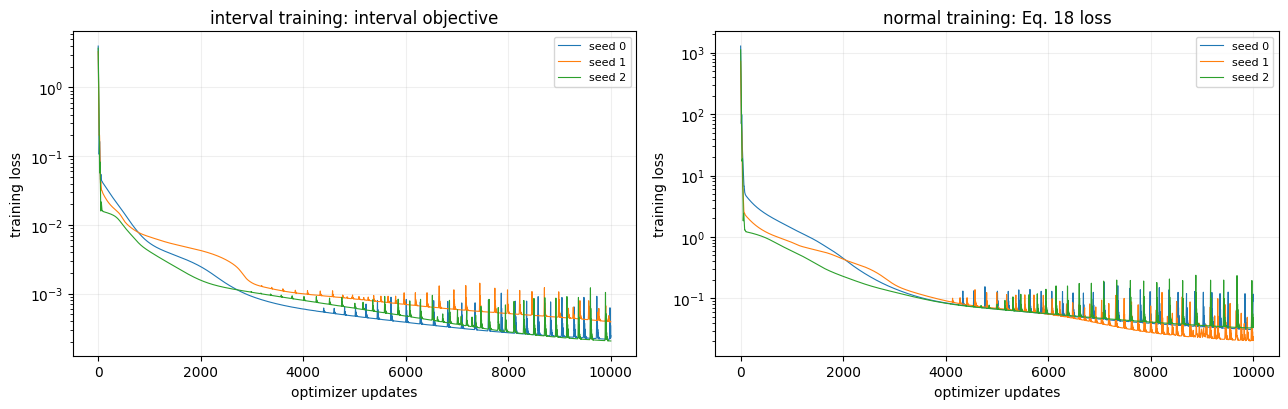

In [6]:
def training_loss(run_dir):
    """(updates, the loss the run minimized) -- the total_loss column of history.csv."""
    with open(run_dir / "history.csv", newline="") as f:
        rows = list(csv.DictReader(f))
    return (np.array([float(r["epoch"]) for r in rows]),
            np.array([float(r["total_loss"]) for r in rows]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for s, color in zip(SEEDS, ("tab:blue", "tab:orange", "tab:green")):
    for ax, runs in ((axes[0], INTERVAL), (axes[1], ORIGINAL)):
        e, loss = training_loss(runs[s])
        ax.semilogy(e, loss, color=color, lw=0.8, label=f"seed {s}")
axes[0].set_title("interval training: interval objective")
axes[1].set_title("normal training: Eq. 18 loss")
for ax in axes:
    ax.set_xlabel("optimizer updates")
    ax.set_ylabel("training loss")
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGS / "observed_intervals_training_loss.pdf")
fig.savefig(FIGS / "observed_intervals_training_loss.png", dpi=150)
plt.show()

## 4. Figure 3 — the paper's unseen condition, clean column

`TG0 = 1.94`, `ROH0 = 1.43`, other species zero, `T = 334.8 K` — not in the training or test
split. The interval-trained seed-0 model is integrated from the initial condition only; no
observation is used. Drawn with the same function as
`chemkan/scripts/figures/plot_biodiesel_interval_fig3.py`, which writes `figures/fig3.pdf`.

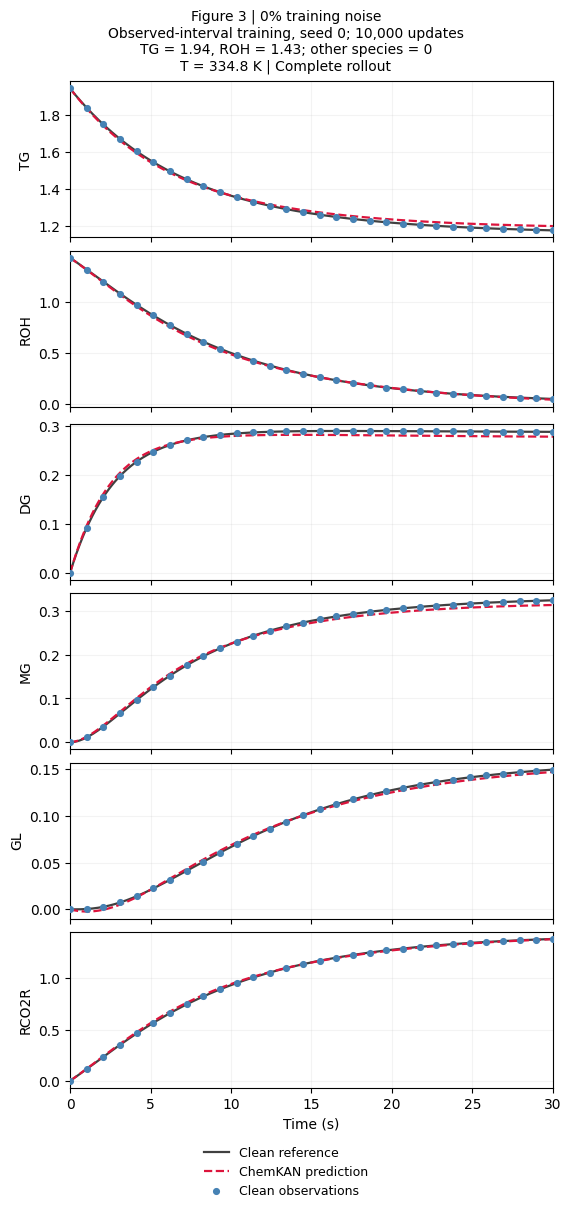

In [7]:
# Figure code: chemkan/scripts/figures/fig03_biodiesel_trajectories.py
from fig03_biodiesel_trajectories import load_condition, plot_clean_condition_column, predict

condition = load_condition(ROOT / "chemkan/data/generated/biodiesel_fig3_condition.npz")
dense = predict(INTERVAL[0] / "checkpoint_final.pt", condition["y0"], condition["T"],
                condition["t_dense"], len(species)).detach().numpy()
plot_clean_condition_column(condition, dense,
                            "Observed-interval training, seed 0; 10,000 updates")
plt.show()

## 5. Clean column at test trajectory 0

The first figure of notebook 07, drawn for the interval-trained seed-0 model: one unseen
test trajectory, dense curve for display, error scored at the 30 observation times.

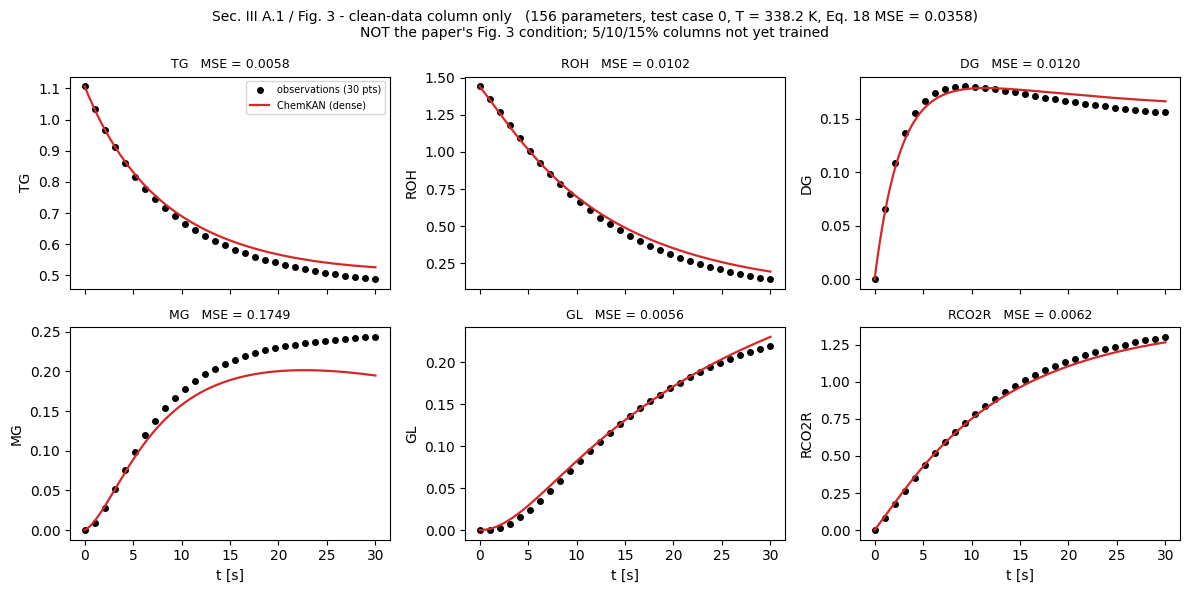

test case 0: Eq. 18 MSE = 0.0358


In [8]:
# Figure code: chemkan/scripts/figures/fig03_biodiesel_trajectories.py
from fig03_biodiesel_trajectories import make_clean_column_figure

_, case0 = make_clean_column_figure(run_dir=INTERVAL[0], case=0, show=True)
print(f"test case 0: Eq. 18 MSE = {case0['case_mse']:.4f}")

## 6. Figure 5B — 0 % noise

Full-rollout training and noise-free test loss over training for interval-trained seed 0,
next to the existing clean DeepONet. Only the 0 % panel exists: interval training was run
on clean data only.

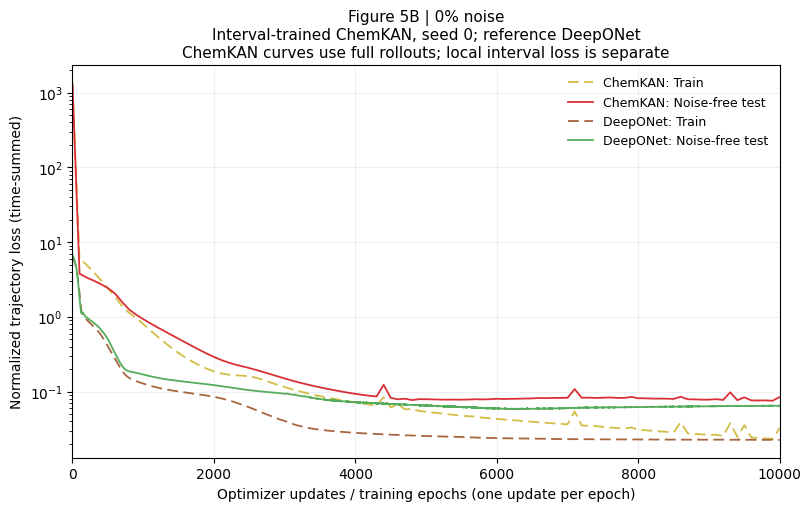

Wrote /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/results/experiments/biodiesel_observed_intervals/figures/fig5b.pdf/.png (clean panel only).


In [9]:
# Figure code: chemkan/scripts/figures/fig05_biodiesel_loss.py
from fig05_biodiesel_loss import make_interval_clean_figure

make_interval_clean_figure(show=True);

## 7. Comparison with the other clean seed-0 runs

These numbers come from each run's own `history.csv`, not from reloading checkpoints: the
KAN-ODE-kernel run does not record its kernel in the checkpoint, so reloading it with
today's code would silently use the paper kernel. Because the loss oscillates strongly from
update to update, each value is the **median over the last 20 % of training** (updates
8,000–10,000).

In [10]:
OTHER_RUNS = {
    "normal training":    ORIGINAL[0],
    "interval training":  INTERVAL[0],
    "Xavier init":        ROOT / "results/experiments/biodiesel_xavier_init/clean_seed0",
    "KAN-ODE RBF kernel": ROOT / "results/experiments/biodiesel_rbf_kanode/clean_seed0",
}

print(f"{'seed 0, clean data':<20}{'train':>9}{'test':>9}")
for name, run in OTHER_RUNS.items():
    e, train, test = history(run)
    late = e >= 8000
    print(f"{name:<20}{np.median(train[late]):>9.4f}{np.median(test[late]):>9.4f}")

seed 0, clean data      train     test
normal training        0.0358   0.0731
interval training      0.0277   0.0796
Xavier init            0.0661   0.1009
KAN-ODE RBF kernel     0.0182   0.0414


## 8. Runtime

Wall time of each paired run, from `history.csv`. `elapsed_seconds` restarts at zero when
a run is resumed, so the segments are added up. For seed 0 the original run's own record is
`main/direct_autograd_seed0` (`clean_replay_seed0`, used above, is its re-run). The runs
shared one machine with up to five concurrent processes, so this is not a clean benchmark.

In [11]:
MAIN0 = ROOT / "results/reproduction/chemkan/biodiesel/main/direct_autograd_seed0"

def wall_time(run_dir):
    # (total wall seconds, number of segments) from history.csv
    with open(run_dir / "history.csv", newline="") as f:
        t = [float(r["elapsed_seconds"]) for r in csv.DictReader(f)]
    ends = [a for a, b in zip(t, t[1:]) if b < a] + [t[-1]]    # last value of each segment
    return sum(ends), len(ends)

runtime = []
for s in SEEDS:
    for name, run in (("observed_interval", INTERVAL[s]),
                      ("original", MAIN0 if s == 0 else ORIGINAL[s])):
        seconds, segments = wall_time(run)
        runtime.append({"seed": s, "procedure": name, "wall_seconds": seconds,
                        "segments": segments,
                        "solver_calls_per_update": 29 if name == "observed_interval" else 1})
        print(f"seed {s}  {name:<18}{seconds:>8.1f} s  ({seconds / 3600:.2f} h, "
              f"{segments} segment{'s' if segments > 1 else ''})")

with open(TABS / "observed_intervals_runtime.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(runtime[0]))
    w.writeheader(); w.writerows(runtime)

seed 0  observed_interval   5493.2 s  (1.53 h, 1 segment)
seed 0  original             628.1 s  (0.17 h, 1 segment)
seed 1  observed_interval   6768.6 s  (1.88 h, 2 segments)
seed 1  original            1072.6 s  (0.30 h, 1 segment)
seed 2  observed_interval   6528.6 s  (1.81 h, 2 segments)
seed 2  original            1084.6 s  (0.30 h, 1 segment)


## Interpretation

**Better fit to the training trajectories, no better on unseen ones.** Interval training
lowers the full-rollout training loss in two of three seeds (seed 0: 0.062 → 0.033,
seed 2: 0.033 → 0.018; seed 1 is a tie), but the test loss is **higher in all three seeds**
(+4 %, +6 %, +27 %). The seeds agree on the direction; the size of the effect is small
and three seeds are few.

**Where the test error goes (section 2).** On test trajectories interval training is about
4× better on TG, ROH and RCO2R, about equal on DG and MG, and about 2× worse on glycerol
(GL). GL and MG carry the largest errors, so they decide the total. This fits what the
method supervises: restarting every interval from an observation never penalizes drift,
and GL, the end product, is the species whose trajectory depends most on accumulated
history.

**Against the other clean seed-0 runs (section 7)**, interval training (test 0.080) and
Xavier initialization (0.101) do not beat normal training (0.073). The KAN-ODE RBF kernel
is the only change so far that clearly lowers the test loss (0.041).

**It is much slower (section 8).** 1.5–1.9 h per run against 0.2–0.3 h for normal
training (6–9×), because every epoch does 29 short solves instead of one long one.

All losses here are Eq. 18, summed over the 30 saved times.